## **Proyecto** | Unidad 3
### **Detección de Fraude en Transacciones Bancarias mediante Técnicas de Agrupamiento y Detección de Anomalías**



#### Analítica Avanzada de Datos |@ IPN-ESCOM
Prof. **César Jesús Núñez Prado**

**Integrantes**:

*   Cortes Moreno Mauricio Hamabiel
*   Maldonado López Alejandro
*   Pacheco Molina Miguel Alejandro
*   Soria Martínez Jesús Armando





### 0° **Intro**



> Librerías

En la siguiente celda se importaron las librerías:

- NumPy para el manejo de arreglos multidimensionales y operaciones matemáticas de alto rendimiento.

- Pandas para la creación, manipulación y análisis de estructuras de datos como DataFrames y Series.

- Kagglehub para importar el conjunto de datos directamente desde Kaggle.

- OS para interactuar con el sistema operativo, por ejemplo, acceder a rutas de archivos o directorios.

- Matplotlib para generar visualizaciones como gráficas de líneas, barras, histogramas, etc.

- Seaborn, una librería de visualización basada en Matplotlib que facilita la creación de gráficas estadísticas con un estilo más atractivo.

- Scikit-learn (sklearn) para el desarrollo de modelos de aprendizaje automático y el preprocesamiento de datos:

- train_test_split para dividir el conjunto de datos en entrenamiento y prueba.

- StandardScaler para la estandarización de las variables numéricas.


- RandomForestClassifier para entrenar un modelo de clasificación basado en ensambles de árboles de decisión.

- Métricas como classification_report, confusion_matrix, roc_auc_score y roc_curve para evaluar el desempeño de los modelos.

- Imbalanced-learn (imblearn) mediante SMOTE, utilizado para el balanceo de clases en conjuntos de datos desbalanceados a través de sobremuestreo sintético.

In [ ]:
pip install minisom

In [ ]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from minisom import MiniSom

In [ ]:
from sklearn.cluster import KMeans

#### Conjunto de datos en un **DataFrame**

> Se descarga el conjunto de datos en una ruta local

* Mediante la libreria de kagglehub se carga el conjunto de datos

In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
print(os.listdir("/kaggle/input/creditcardfraud"))

['creditcard.csv']


* Una vez cargado se visualiza

In [ ]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df = df.rename(columns={
    'Time' : "Tiempo",
    'Amount' : "Monto",
    'Class' : "Clase"
})

#### 1° **Exploracion del Conjunto de Datos**

> Información general del conjunto de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Tiempo  284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

* Se describe el conjunto de datos por cada variable

In [ ]:
print(df.describe().T)

           count          mean           std         min           25%  \
Tiempo  284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1      284807.0  1.168375e-15      1.958696  -56.407510     -0.920373   
V2      284807.0  3.416908e-16      1.651309  -72.715728     -0.598550   
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4      284807.0  2.074095e-15      1.415869   -5.683171     -0.848640   
V5      284807.0  9.604066e-16      1.380247 -113.743307     -0.691597   
V6      284807.0  1.487313e-15      1.332271  -26.160506     -0.768296   
V7      284807.0 -5.556467e-16      1.237094  -43.557242     -0.554076   
V8      284807.0  1.213481e-16      1.194353  -73.216718     -0.208630   
V9      284807.0 -2.406331e-15      1.098632  -13.434066     -0.643098   
V10     284807.0  2.239053e-15      1.088850  -24.588262     -0.535426   
V11     284807.0  1.673327e-15      1.020713   -4.797473     -0.762494   
V12     284807.0 -1.247012e-15      0.

* Primero se visualiza si hay nulos

In [ ]:
print("\n=== NULOS ===")
print(df.isnull().sum())


=== NULOS ===
Tiempo    0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Monto     0
Clase     0
dtype: int64


* Mediante una distribuciòn de clases para un analisis de desbalance

/tmp/ipython-input-4049985594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Clase", palette="viridis")


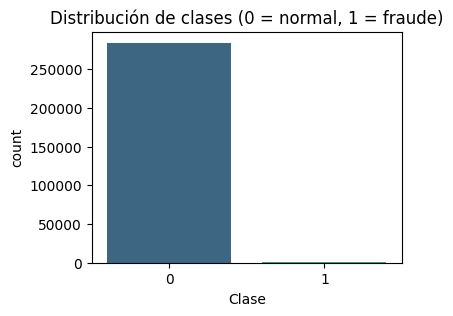

Tasa de fraude: 0.1727%


In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="Clase", palette="viridis")
plt.title("Distribución de clases (0 = normal, 1 = fraude)")
plt.show()

fraude_rate = df["Clase"].mean() * 100
print(f"Tasa de fraude: {fraude_rate:.4f}%")


Se visualiza que hay un desbalance entre clases, favoreciendo a la clase de 'no fraude`.

* Se visualiza mediante una distribuciòn si la variable 'amount' que se refiere a la cantidad de la transaccion para visualizar valores atípicos, junto con una diagrama de boxplot

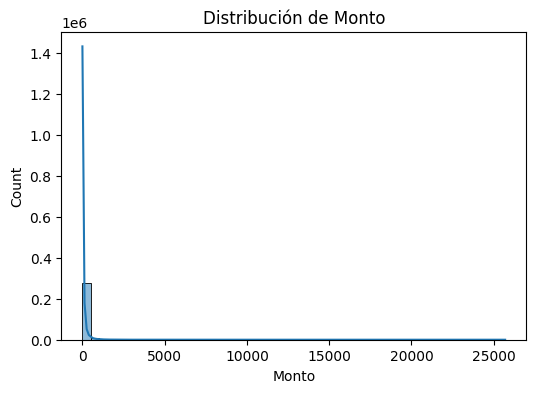

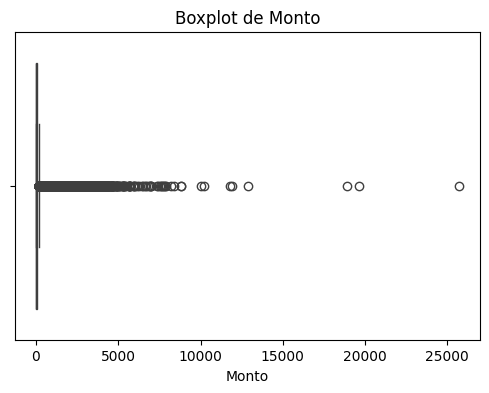

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Monto"], bins=50, kde=True)
plt.title("Distribución de Monto")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Monto"])
plt.title("Boxplot de Monto")
plt.show()

* Tambien se analiza la variable 'time' donde se ve la distribuciòn del tiempo en que se hace una transacciòn

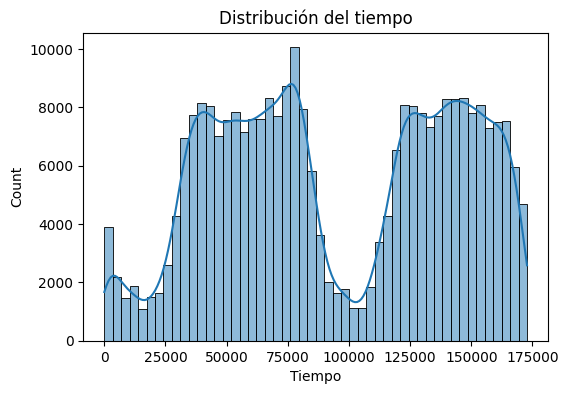

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Tiempo"], bins=50, kde=True)
plt.title("Distribución del tiempo")
plt.show()

* Se utilizò PCA para visualizar si hay una diferencia entre trasacciones calsificadas como fraude de las que no.

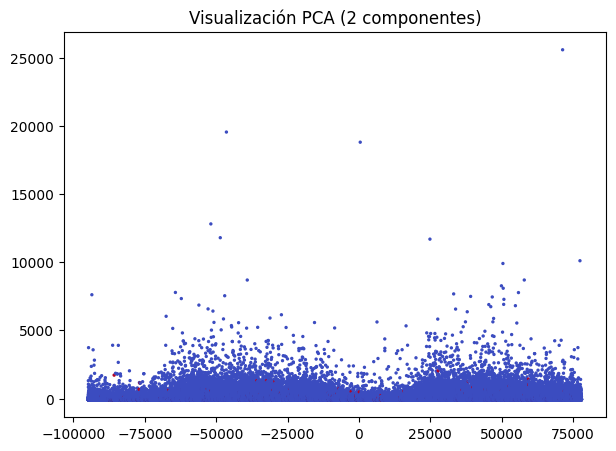

In [ ]:
from sklearn.decomposition import PCA

X = df.drop("Clase", axis=1)
y = df["Clase"]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(pca_result[:,0], pca_result[:,1], c=y, s=2, cmap="coolwarm")
plt.title("Visualización PCA (2 componentes)")
plt.show()


## Transformación

* Para poder hacer la comparaciòn entre un modelo de clasificadcion frente a un modelo donde se ocupa una modelo de agrupamiento + uno de clasificacion ,se hace el entrenemiento de una Bosque Aleatorio para visualizar su rendimiento.

In [ ]:
X = df.drop("Clase", axis=1)
y = df["Clase"]

* Se divide en 80% entrenmeinto y 20% prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

* Par poder mejorar el rendimiento y complejidad del modelo, se aplica un escalamiento a todas las variables

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

* Para afrontar el desbalance se ocupa SMOTE

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

## Modelado de un clasificador

* Se entena el modelo

In [ ]:
rf = RandomForestClassifier(
    class_weight=None,
    random_state=7
)

rf.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=7)

In [ ]:
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]


[[56852    12]
 [   19    79]]


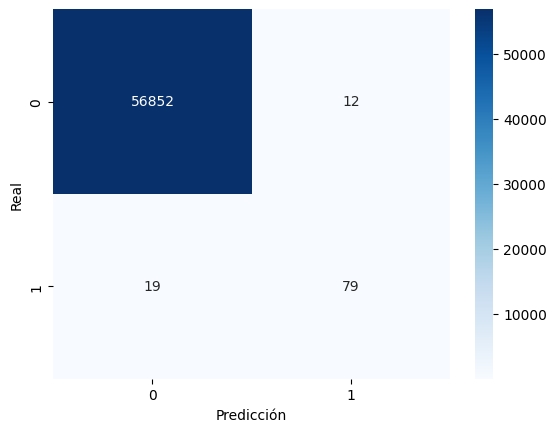

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


*  Se visualiza el resultado

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.81      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



* Curva de ROC

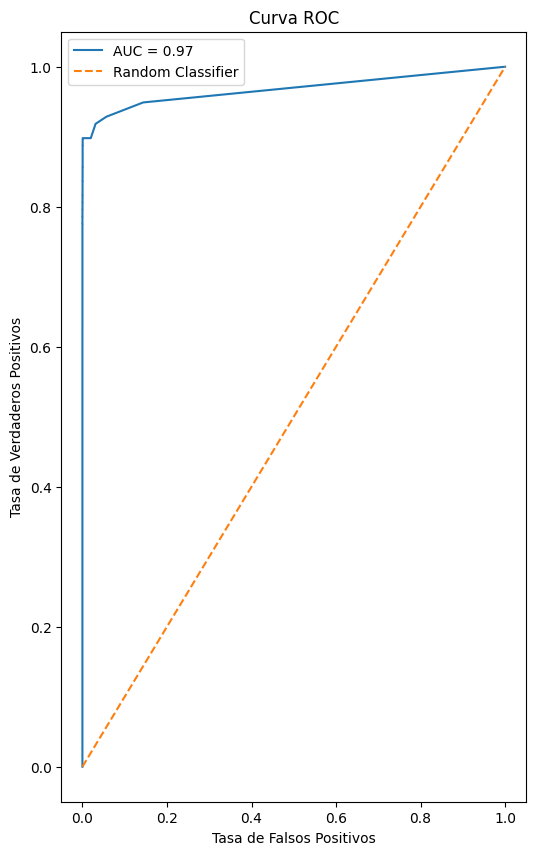

In [ ]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,10))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

## Implementaciòn de modelos de agrupamiento + clasificador

#### Se prueba con un modelo K-Means + Bosques aleatorios

* Mediante el mètodo del codo se busca encontrar el k mas optimo

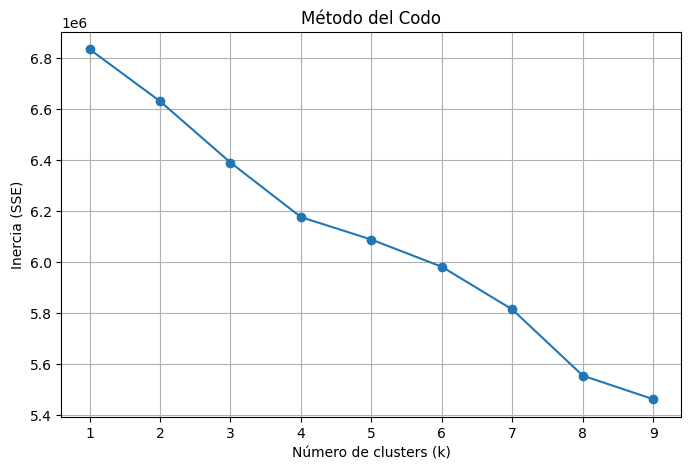

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)   # Usa tus datos escalados
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (SSE)')
plt.grid(True)
plt.show()


* Al no visulizarse un codo pronunciado, mediante Silhoutte se busca confirmar e k mas optimo

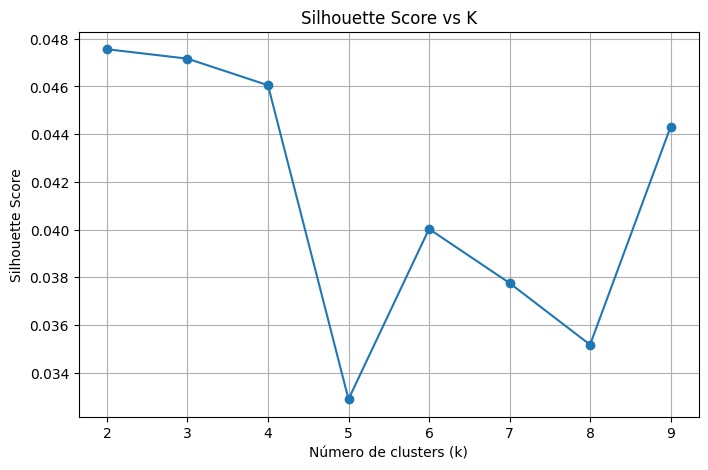

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.utils import resample

# Subsamplear el train a algo manejable
X_sub = resample(X_train_scaled, n_samples=20000, random_state=42)

sil_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette Score vs K')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


* Una vez encontrado el k mas optimo, se entrena el k-means para aplicarlo

In [ ]:
kmeans = KMeans(
    n_clusters=4, #manualmente colocamos el k mas optimo
    random_state=42,
    n_init='auto'
)

kmeans.fit(X_train_scaled)


KMeans(n_clusters=4, random_state=42)

* Visualizamos los clùsteres con PCA

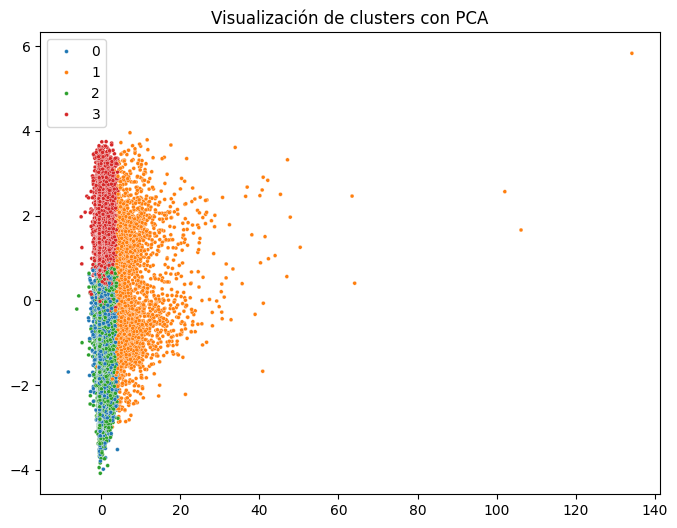

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

clusters_train = kmeans.predict(X_train_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=clusters_train,
    palette='tab10',
    s=8
)
plt.title("Visualización de clusters con PCA")
plt.show()


* Se analiza los clusters

In [ ]:
df_temp = pd.DataFrame({
    "cluster": clusters_train,
    "target": y_train
})

cluster_summary = df_temp.groupby("cluster")["target"].mean()
print("Porcentaje de fraude por cluster:\n", cluster_summary)


Porcentaje de fraude por cluster:
 cluster
0    0.001271
1    0.030837
2    0.001103
3    0.001287
Name: target, dtype: float64


#### Asignamos nuevas caracteristicas

* Para poder mejorar el rendimiento, con los resultados del agrupamiento se generan nuevas caracteristicas

1. Primero, agremamos al conjunto de datos la caracteritica de id_cluster, dependiendo a que cluster pertenece cada transaccion 0, 1, 2 o 3.

In [ ]:
# Etiquetas de cluster
cluster_train = kmeans.predict(X_train_scaled)
cluster_test  = kmeans.predict(X_test_scaled)

2. Se calcula la distancia de cada transacción de sus centroide para identificar:
* Distancia pequeña → transacción típica


* Distancia grande → transacción atípica → posible fraude

In [ ]:
# Distancias a TODOS los centroides
dists_train = kmeans.transform(X_train_scaled)
dists_test  = kmeans.transform(X_test_scaled)

3. Posterior se calcula la "confianza" de que esa transacción pertenezca a ese clúster, es decir, la confianza de pertenencia al cluster se define como la diferencia entre la distancia al centroide más cercano y al segundo más cercano.

* Valor pequeño → punto ambiguo → sospechoso

* Valor grande → comportamiento claro


Esto para identificar ambiguedades

In [ ]:
min_dist_train = dists_train.min(axis=1)
min_dist_test  = dists_test.min(axis=1)

sorted_dists_train = np.sort(dists_train, axis=1)
sorted_dists_test  = np.sort(dists_test, axis=1)

cluster_confidence_train = sorted_dists_train[:, 1] - sorted_dists_train[:, 0]
cluster_confidence_test  = sorted_dists_test[:, 1] - sorted_dists_test[:, 0]

4. Por ultimo asignamos estas nuevas caracteristicas al conjunto de datos

In [ ]:
X_train_hybrid = np.column_stack((
    X_train,
    cluster_train,
    min_dist_train,
    cluster_confidence_train
))

X_test_hybrid = np.column_stack((
    X_test,
    cluster_test,
    min_dist_test,
    cluster_confidence_test
))


* Se usa SMOTE para el desbalance

In [ ]:
X_train_hybrid_res, y_train_res = sm.fit_resample(X_train_hybrid, y_train)

* Se entrena nuevamente el modelo de clasificaciòn

In [ ]:
rf = RandomForestClassifier(
    class_weight=None,
    random_state=7
)

rf.fit(X_train_hybrid_res, y_train_res)


RandomForestClassifier(random_state=7)

In [ ]:
y_pred = rf.predict(X_test_hybrid)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



[[56847    17]
 [   15    83]]


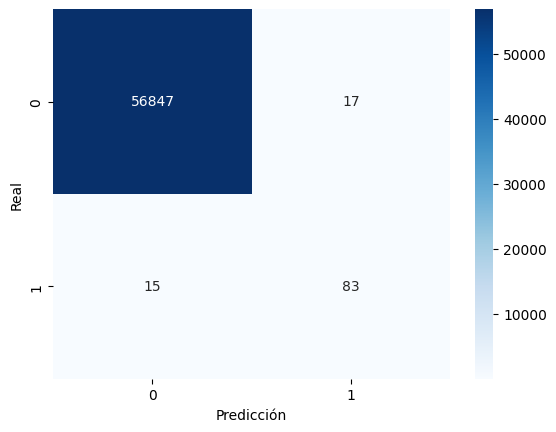

In [ ]:
cm_hybrid = confusion_matrix(y_test, y_pred)
print(cm_hybrid)

sns.heatmap(cm_hybrid, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

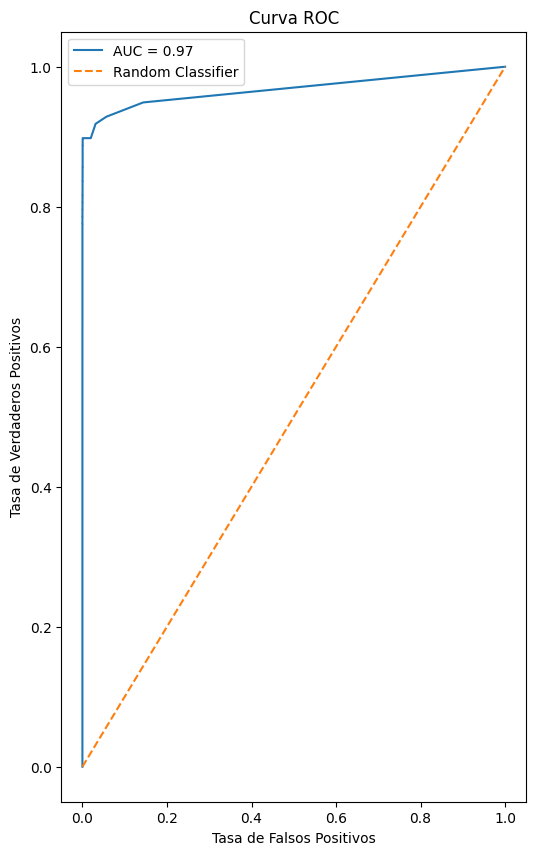

In [ ]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,10))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

---


###(SOM + K-Means) + Bosques aleatorios

### Dimensiones del SOM

Se definen las dimensiones del mapa autoorganizado (SOM), las cuales determinan el número de neuronas.

In [ ]:
som_x = 10
som_y = 15

### Entrenamiento del SOM

En esta celda se inicializa y entrena el SOM utilizando los datos escalados, permitiendo capturar relaciones no lineales y preservar la topología del espacio de características.

In [ ]:
som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X_train_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.2,
    random_seed=7
)

som.random_weights_init(X_train_scaled)
som.train_random(X_train_scaled, 30000, verbose=True)

 [ 30000 / 30000 ] 100% - 0:00:00 left 
 quantization error: 3.0585846601259967


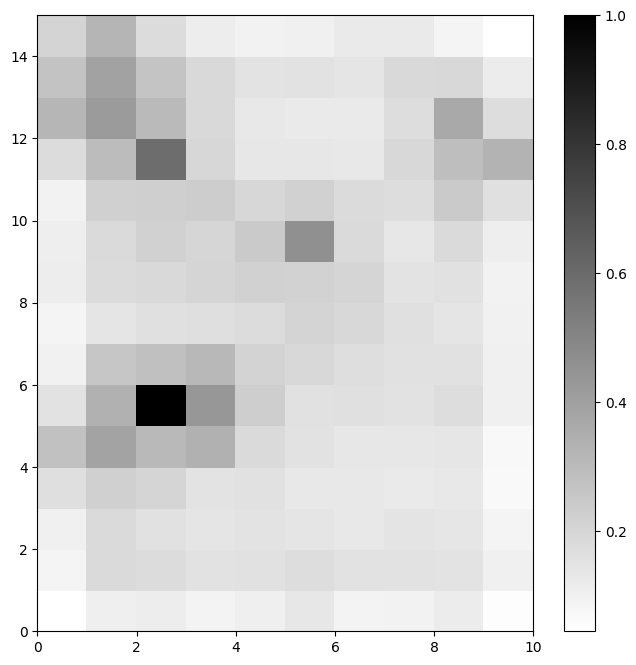

In [ ]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='gist_yarg')
plt.colorbar()
plt.show()

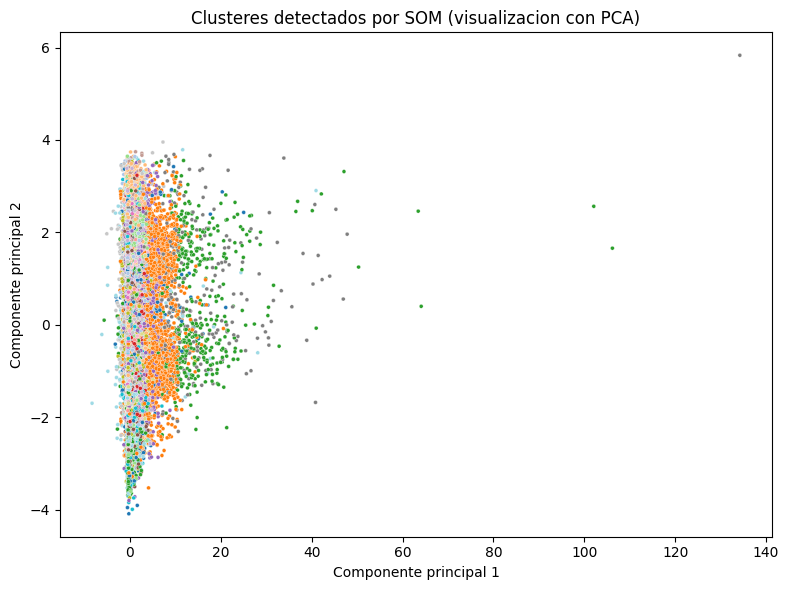

In [ ]:
# PCA a 2 componentes sobre los datos de entrenamiento
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Neurona ganadora (BMU) para cada muestra
bmu_train = np.array([som.winner(x) for x in X_train_scaled])

# Convierte BMU a etiquetas para graficar
bmu_labels = [f"{i}-{j}" for i, j in bmu_train]

# DataFrame para visualización
pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
pca_df["BMU"] = bmu_labels

# Gráfica
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="BMU",
    palette="tab20",
    s=8,
    legend=False
)

plt.title("Clusteres detectados por SOM (visualizacion con PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.tight_layout()
plt.show()

### Pesos del SOM

En esta celda se extraen los vectores de pesos finales del SOM, y serán utilizados para el agrupamiento posterior.

In [ ]:
som_weights = som.get_weights()
som_weights_flat = som_weights.reshape(-1, som_weights.shape[2])

### KMeans sobre los pesos del SOM

Se aplica K-means sobre los pesos del SOM para agrupar las neuronas en clústeres globales, combinando la estructura topológica del SOM con un método de agrupamiento.

In [ ]:
k_som = 4

kmeans_som = KMeans(
    n_clusters=k_som,
    random_state=42,
    n_init='auto'
)

kmeans_som.fit(som_weights_flat)

KMeans(n_clusters=4, random_state=42)

### BMU (neurona ganadora)

En esta celda se identifica la neurona ganadora del SOM para cada transacción, asociando cada observación a una región específica del mapa.

In [ ]:
bmu_train = np.array([som.winner(x) for x in X_train_scaled])
bmu_test  = np.array([som.winner(x) for x in X_test_scaled])

### Conversión BMU -> índice lineal

Se convierten las coordenadas bidimensionales del SOM a un índice lineal, necesario para relacionar cada transacción con el clúster asignado por K-means.

In [ ]:
def bmu_to_index(bmu, som_y):
    return bmu[:, 0] * som_y + bmu[:, 1]

bmu_idx_train = bmu_to_index(bmu_train, som_y)
bmu_idx_test  = bmu_to_index(bmu_test, som_y)

### Cluster final SOM + KMeans

Se asigna a cada transacción la etiqueta de clúster resultante de la combinación SOM + K-means, generando una nueva característica para el modelo de clasificación.

In [ ]:
cluster_train = kmeans_som.labels_[bmu_idx_train]
cluster_test  = kmeans_som.labels_[bmu_idx_test]

### Análisis de fraude por cluster SOM + KMeans

En esta celda se analiza la proporción promedio de transacciones fraudulentas dentro de cada clúster generado por la combinación SOM + K-means, con el objetivo de evaluar si los grupos identificados presentan comportamientos diferenciados respecto al fraude.

In [ ]:
df_temp = pd.DataFrame({
    "cluster": cluster_train,
    "target": y_train.values
})

cluster_summary = df_temp.groupby("cluster")["target"].mean()
print("Porcentaje de fraude por cluster (SOM + KMeans):\n")
print(cluster_summary)

Porcentaje de fraude por cluster (SOM + KMeans):

cluster
0    0.000272
1    0.003294
2    0.004831
3    0.000235
Name: target, dtype: float64


### Distancias a centroides

Las distancias se calculan sobre los pesos del SOM asociados a cada muestra, no sobre los datos originales.


Se calculan las distancias entre la representación SOM de cada transacción y todos los centroides obtenidos por K-means. Estas distancias se utilizan como una medida de qué tan representativa o atípica es una transacción dentro de su clúster.

In [ ]:
# centroides de KMeans
centroids = kmeans_som.cluster_centers_

# pesos SOM asociados a cada muestra
som_repr_train = som_weights_flat[bmu_idx_train]
som_repr_test  = som_weights_flat[bmu_idx_test]

# distancias a todos los centroides
dists_train = np.linalg.norm(
    som_repr_train[:, None, :] - centroids[None, :, :],
    axis=2
)

dists_test = np.linalg.norm(
    som_repr_test[:, None, :] - centroids[None, :, :],
    axis=2
)

### Distancia mínima y confianza de pertenencia

Posterior se calcula la "confianza" de que esa transacción pertenezca a ese clúster, es decir, la confianza de pertenencia al cluster se define como la diferencia entre la distancia al centroide más cercano y al segundo más cercano.

* Valor pequeño → punto ambiguo → sospechoso

* Valor grande → comportamiento claro


Esto para identificar ambiguedades

In [ ]:
# distancia mínima
min_dist_train = dists_train.min(axis=1)
min_dist_test  = dists_test.min(axis=1)

# confianza (2da distancia - 1ra distancia)
sorted_dists_train = np.sort(dists_train, axis=1)
sorted_dists_test  = np.sort(dists_test, axis=1)

cluster_confidence_train = sorted_dists_train[:, 1] - sorted_dists_train[:, 0]
cluster_confidence_test  = sorted_dists_test[:, 1] - sorted_dists_test[:, 0]

### Construcción del dataset híbrido final

Se asignan estas nuevas caracteristicas al conjunto de datos.

In [ ]:
X_train_hybrid_som = np.column_stack((
    X_train.values,
    cluster_train,
    min_dist_train,
    cluster_confidence_train
))

X_test_hybrid_som = np.column_stack((
    X_test.values,
    cluster_test,
    min_dist_test,
    cluster_confidence_test
))

### Balanceo con SMOTE

Se aplica la técnica SMOTE para corregir el desbalance de clases en el conjunto de entrenamiento, generando ejemplos sintéticos de la clase minoritaria y mejorando el aprendizaje del modelo de clasificación.

In [ ]:
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(
    X_train_hybrid_som, y_train
)

### Entrenamiento del TERCER Random Forest

In [ ]:
rf_som = RandomForestClassifier(
    class_weight=None,
    random_state=7,
    # n_jobs=-1
)

rf_som.fit(X_train_res, y_train_res)

y_pred = rf_som.predict(X_test_hybrid_som)
y_proba = rf_som.predict_proba(X_test_hybrid_som)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



[[56851    13]
 [   18    80]]


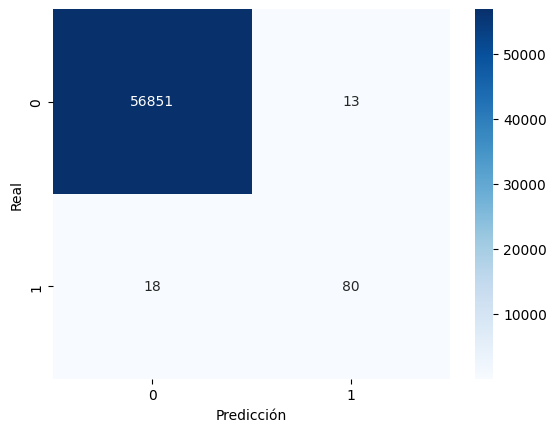

In [ ]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
#plt.title("RF + SOM + KMeans")
plt.show()

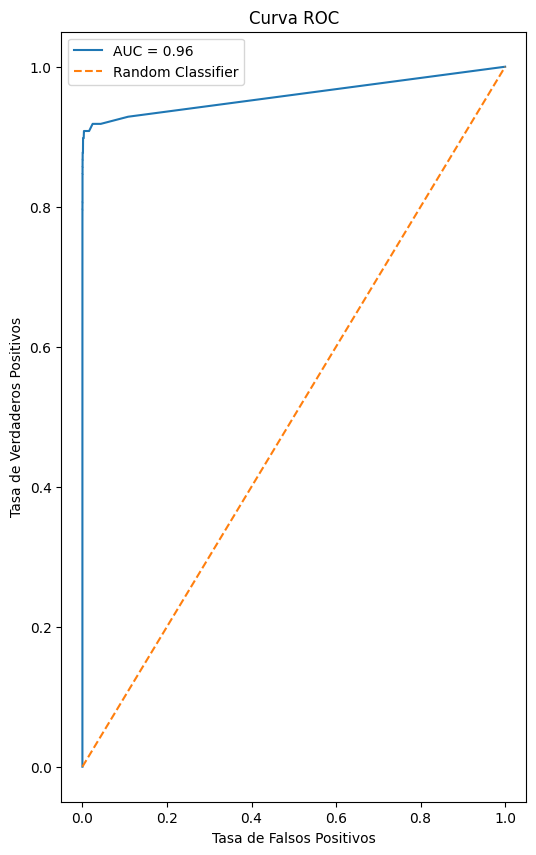

In [ ]:
# Curva ROC y AUC

auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,10))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

| Modelo            | Recall (fraude) | TP     | FN     | Precision |
| ----------------- | --------------- | ------ | ------ | --------- |
| RF normal         | 0.81            | 79     | 19     | **0.87**  |
| **KMeans + RF**   | **0.85**        | **83** | **15** | 0.83      |
| SOM + KMeans + RF | 0.82            | 80     | 18     | 0.86      |


### Implementación del mejor algoritmo

In [ ]:
nueva_transaccion = np.array([[
    -1.23, 0.45, 2.31, -0.87, 0.12,
    -0.55, 1.02, -0.33, 0.76, -1.11,
    0.05, 0.91, -0.48, 0.62, -0.14,
    0.88, -0.03, 0.27, -1.05, 0.19,
    -0.22, 0.41, -0.09, 0.56,
    0.13, -0.07, 0.24, -0.18, 0.03, 149.62
]])


In [ ]:
def clasificar_transaccion_kmeans(transaccion_nueva, escalador,kmeans, modelo_rf,umbral=0.5):

    transaccion_escalada = escalador.transform(transaccion_nueva)#se hace el escalado

    cluster_kmeans = kmeans.predict(transaccion_escalada) #se asigna el cluster

    distancias = kmeans.transform(transaccion_escalada) #se asigna la distancia entre centroides

    distancia_minima = distancias.min(axis=1)
    distancias_ordenadas = np.sort(distancias, axis=1)     #la confianza
    confianza_cluster = distancias_ordenadas[:, 1] - distancias_ordenadas[:, 0]

    vector_hibrido = np.column_stack((transaccion_nueva, cluster_kmeans, distancia_minima, confianza_cluster)) #se suman las nuevas caracteristicas

    probabilidad_fraude = modelo_rf.predict_proba(vector_hibrido)[0, 1] #la prob de rf
    prediccion = int(probabilidad_fraude >= umbral)

    return prediccion, probabilidad_fraude



In [ ]:
prediccion, probabilidad = clasificar_transaccion_kmeans(nueva_transaccion, scaler, kmeans, rf, umbral=0.30)

print("Predicción:", "Fraude" if prediccion == 1 else "No fraude")
print("Probabilidad de fraude:", probabilidad)


Predicción: No fraude
Probabilidad de fraude: 0.01


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Conclusiones

__Soria Martínez Jesús Armando__

El fraude bancario representa un problema de alta relevancia, al que tanto las instituciones financieras como los usuarios están constantemente expuestos. Por ello, resulta fundamental proponer soluciones que permitan mejorar su detección, incluso en escenarios donde existe un fuerte desbalance entre transacciones legítimas y fraudulentas.

En este proyecto se entrenó inicialmente un modelo base de Random Forest utilizando únicamente las variables originales del conjunto de datos, con el fin de establecer una línea de referencia. Posteriormente, se propusieron dos enfoques alternativos basados en técnicas de aprendizaje no supervisado para enriquecer el conjunto de características. El primero consistió en la incorporación de variables derivadas del algoritmo K-means, mientras que el segundo combinó un mapa autoorganizado (SOM) con K-means, integrando posteriormente esta información en un nuevo modelo de Random Forest.

De acuerdo con los resultados obtenidos, ambas propuestas superaron el desempeño del modelo base. El modelo que incorporó características generadas mediante SOM y K-means logró una mejora en la métrica de recall, mientras que la propuesta basada únicamente en K-means no solo superó la línea base en recall, sino que además redujo de manera considerable el número de falsos positivos. Estos resultados indican que los algoritmos de agrupamiento son capaces de capturar información estructural adicional en los datos, la cual resulta valiosa para mejorar la capacidad de clasificación del modelo supervisado, aun en presencia de un marcado desbalance de clases.


**Cortes Moreno Mauricio Hamabiel**

En este trabajo se desarrolló una herramienta orientada a la detección de fraude mediante la combinación de técnicas de aprendizaje no supervisado y aprendizaje supervisado, con el objetivo de mejorar la capacidad de identificación de patrones y reducir pérdidas monetarias.

La metodología  integra algoritmos de agrupamiento, específicamente K-Medias y Mapas Autoorganizados (SOM), para extraer información y patrones de comportamiento presentes en los datos para posteriormente, como nuevas características, complementar el conjunto de datos y con un modelo de clasificación basado en Bosque Aleatorio permita tener un mejor desempeño. Durante la experimentación, los resultados demostraron que el modelo que combina K-Medias y Bosque Aleatorio obtuvo el mejor desempeño en términos de manejo de errores de clasificación, logrando un balance adecuado entre falsos positivos y falsos negativos. En particular, se observó una mejora relevante en la reducción de falsos negativos, aspecto fundamental en escenarios de fraude, ya que estos representan transacciones fraudulentas que no son detectadas y que pueden generar pérdidas económicas significativas, pora incorporación de técnicas de agrupamiento como etapa previa al proceso de clasificación aporta información relevante sobre el comportamiento de las transacciones, lo que permite al modelo identificar con mayor eficacia patrones asociados al fraude. Los resultados obtenidos respaldan el uso de enfoques híbridos como una alternativa efectiva para la detección de fraude en sistemas financieros, especialmente cuando se prioriza la minimización de fraudes no detectados.

__Maldonado López Alejandro__


En este proyecto se abordó el problema de la detección de fraude en transacciones bancarias mediante un enfoque híbrido que combina técnicas de aprendizaje supervisado y no supervisado, siguiendo la metodología CRISP-DM. Los resultados muestran que Bosques Aleatorios ofrece un desempeño sólido en la detección de fraude, incluso en un conjunto de datos altamente desbalanceado. La incorporación de técnicas no supervisadas como K-Medias y SOM mejora la detección de la clase fraudulenta, incrementando el recall y reduciendo falsos negativos. Las métricas globales (F1-macro ≈ 0.92 y AUC-ROC ≈ 0.97) confirman una alta capacidad discriminativa de los modelos. El enfoque híbrido permite capturar tanto patrones conocidos como comportamientos anómalos, ofreciendo una solución robusta y alineada con el contexto del negocio financiero.

__Pacheco Molina Miguel Alejandro__

En este proyecto demostramos que la integración de técnicas no supervisadas con modelos supervisados constituye una estrategia superior para la detección de fraude bancario en entornos de alto desbalance. El modelo propuesto como línea base (Random Forest con SMOTE) ofreció un rendimiento sólido con un Recall de 0.81, pero la implementación de modelos híbridos nos permitió superar este desempeño. El modelo de KMeans + RF resultó ser el más eficaz para minimizar las pérdidas financieras directas, alcanzando el Recall máximo de 0.85. Por otro lado, el modelo más avanzado de SOM + KMeans + RF resultó con el mejor equilibrio operativo entre detección y fiabilidad (Recall 0.82 y Precisión 0.86), así confirmamos que la incorporación de información geométrica y topológica ya sea mediante centroides globales o mapas autoorganizados nos permitió capturar patrones de fraude complejos que los clasificadores tradicionales por sí solos no logran identificar.
